# Final Project Proposal & Exploratory Data Analysis
## Predicting 30-Day Hospital Readmission in Diabetic Patients

Data Selection

For my project, I'm proposing to use the  Diabetes 130-US Hospitals for Years 1999–2008 dataset from the UC Irvine Machine Learning Repository (https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

The dataset comes from the Health Facts database (Cerner), which includes ten years of inpatient diabetic encounters at 130 US hospitals and integrated delivery networks (Strack et al., 2014). The target variable is readmitted, which has the values `<30`, `>30`, `NO`, and the binary target will specifically be 1 is readmitted is `<30` and 0 otherwise.

I chose this dataset because my capstone project will be on heart failure readmission prediction, so exploring a different chronic condition and its readmission factors may be helpful for my overall goal. This dataset has many clinical features across demographics and lab results, and the data seems to be large and overall well documented.

Specifically in terms of predictor variables, there's data on demographics (race, gender, age weight), Admission and discharge (admisson_type_id, admission_source_id, etc), the hospital stay length(time_in_hosiptal), diagnoses, lab results, and treatment summary, all of which provide a comprehensive view of the patient's inpatient care and can provide some predictive support for potential readmission risk.



In [2]:
!pip install -q ucimlrepo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

diab = fetch_ucirepo(id=296)

X = diab.data.features.copy()
y = diab.data.targets.copy()
ids = diab.data.ids.copy() if diab.data.ids is not None else pd.DataFrame(index=X.index)

print("Dataset  :", diab.metadata["name"])
print("Features :", X.shape, "| Targets:", y.shape, "| ID columns:", list(ids.columns))

Dataset  : Diabetes 130-US Hospitals for Years 1999-2008
Features : (101766, 47) | Targets: (101766, 1) | ID columns: ['encounter_id', 'patient_nbr']


/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [4]:
diab.variables

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,None,Unique identifier of an encounter,None,no
1,patient_nbr,ID,,None,Unique identifier of a patient,None,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",None,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20...",None,no
5,weight,Feature,Categorical,None,Weight in pounds.,None,yes
6,admission_type_id,Feature,Categorical,None,Integer identifier corresponding to 9 distinct...,None,no
7,discharge_disposition_id,Feature,Categorical,None,Integer identifier corresponding to 29 distinc...,None,no
8,admission_source_id,Feature,Categorical,None,Integer identifier corresponding to 21 distinc...,None,no
9,time_in_hospital,Feature,Integer,None,Integer number of days between admission and d...,None,no


In [23]:
df = pd.concat([ids, X, y], axis=1).replace("?", np.nan)

target_col = y.columns[0]
print("Original target values:\n", df[target_col].value_counts(dropna=False), "\n")

df["target"] = (df[target_col].astype(str).str.strip() == "<30").astype(int)

feature_cols = list(X.columns)
df.head()

Original target values:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64 



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [6]:
print("Shape:", df.shape, "\n")
df.info()

Shape: (101766, 51) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

In [7]:
num_cols = [c for c in ["time_in_hospital", "num_lab_procedures", "num_procedures",
                        "num_medications", "number_outpatient", "number_emergency",
                        "number_inpatient", "number_diagnoses"] if c in df.columns]

med_cols = [c for c in ["metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
                        "acetohexamide","glipizide","glyburide","tolbutamide","pioglitazone",
                        "rosiglitazone","acarbose","miglitol","troglitazone","tolazamide",
                        "examide","citoglipton","insulin","glyburide-metformin",
                        "glipizide-metformin","glimepiride-pioglitazone",
                        "metformin-rosiglitazone","metformin-pioglitazone"] if c in df.columns]

id_coded = [c for c in ["admission_type_id", "discharge_disposition_id", "admission_source_id"] if c in df.columns]

cat_cols = [c for c in feature_cols if c not in num_cols]
print(f"Numeric features     ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}), of which")
print(f"   - integer-coded categories ({len(id_coded)}): {id_coded}")
print(f"   - medication columns       ({len(med_cols)})")
print(f"   - other (demographics, diagnoses, labs, etc.): {[c for c in cat_cols if c not in id_coded + med_cols]}")

Numeric features     (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical features (39), of which
   - integer-coded categories (3): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
   - medication columns       (23)
   - other (demographics, diagnoses, labs, etc.): ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']


In [8]:
print("Original 3-class distribution:")
print(pd.DataFrame({"count": df[target_col].value_counts(),
                    "share": df[target_col].value_counts(normalize=True)}), "\n")

print("Binary target distribution:")
tc = df["target"].value_counts().sort_index()
print(pd.DataFrame({"count": tc, "share": tc / tc.sum()}))
print(f"\nMajority-class baseline accuracy: {1 - df['target'].mean():.3%}")
print(f"Imbalance ratio (neg : pos) = {tc[0] / tc[1]:.1f} : 1")

Original 3-class distribution:
            count  share
readmitted              
NO          54864  0.539
>30         35545  0.349
<30         11357  0.112 

Binary target distribution:
        count  share
target              
0       90409  0.888
1       11357  0.112

Majority-class baseline accuracy: 88.840%
Imbalance ratio (neg : pos) = 8.0 : 1


In [9]:
df[num_cols].describe().T.assign(skew=df[num_cols].skew(), n_missing=df[num_cols].isna().sum())

,count,mean,std,min,25%,50%,75%,max,skew,n_missing
time_in_hospital,"101,766.000",4.396,2.985,1.000,2.000,4.000,6.000,14.000,1.134,0
num_lab_procedures,"101,766.000",43.096,19.674,1.000,31.000,44.000,57.000,132.000,-0.237,0
num_procedures,"101,766.000",1.340,1.706,0.000,0.000,1.000,2.000,6.000,1.316,0
num_medications,"101,766.000",16.022,8.128,1.000,10.000,15.000,20.000,81.000,1.327,0
number_outpatient,"101,766.000",0.369,1.267,0.000,0.000,0.000,0.000,42.000,8.833,0
number_emergency,"101,766.000",0.198,0.930,0.000,0.000,0.000,0.000,76.000,22.856,0
number_inpatient,"101,766.000",0.636,1.263,0.000,0.000,0.000,1.000,21.000,3.614,0
number_diagnoses,"101,766.000",7.423,1.934,1.000,6.000,8.000,9.000,16.000,-0.877,0


In [10]:
cat_summary = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(dropna=True),
    "n_missing": df[cat_cols].isna().sum(),
    "pct_missing": df[cat_cols].isna().mean() * 100,
    "most_common": df[cat_cols].mode().iloc[0],
    "most_common_pct": [df[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_cols],
})
cat_summary.sort_values("pct_missing", ascending=False)

,n_unique,n_missing,pct_missing,most_common,most_common_pct
weight,9,98569,96.858,[75-100),41.789
max_glu_serum,3,96420,94.747,Norm,48.578
A1Cresult,3,84748,83.277,>8,48.278
medical_specialty,72,49949,49.082,InternalMedicine,28.244
payer_code,17,40256,39.557,MC,52.738
race,5,2273,2.234,Caucasian,76.487
diag_3,789,1423,1.398,250,11.516
diag_2,748,358,0.352,276,6.658
diag_1,716,21,0.021,428,6.744
admission_source_id,17,0,0.000,7,56.496


In [11]:
for c in ["age", "gender", "race", "change", "diabetesMed", "A1Cresult", "max_glu_serum"]:
    if c in df.columns:
        print(f"\n--- 30-day readmission rate by {c} ---")
        print(df.groupby(c, dropna=False)["target"].agg(rate="mean", n="count").sort_index())


--- 30-day readmission rate by age ---
          rate      n
age                  
[0-10)   0.019    161
[10-20)  0.058    691
[20-30)  0.142   1657
[30-40)  0.112   3775
[40-50)  0.106   9685
[50-60)  0.097  17256
[60-70)  0.111  22483
[70-80)  0.118  26068
[80-90)  0.121  17197
[90-100) 0.111   2793

--- 30-day readmission rate by gender ---
                 rate      n
gender                      
Female          0.112  54708
Male            0.111  47055
Unknown/Invalid 0.000      3

--- 30-day readmission rate by race ---
                 rate      n
race                        
AfricanAmerican 0.112  19210
Asian           0.101    641
Caucasian       0.113  76099
Hispanic        0.104   2037
Other           0.096   1506
NaN             0.083   2273

--- 30-day readmission rate by change ---
        rate      n
change             
Ch     0.118  47011
No     0.106  54755

--- 30-day readmission rate by diabetesMed ---
             rate      n
diabetesMed             
No          0.

/tmp/ipykernel_438/4206610358.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, order=order3, palette="Blues_d", ax=axes[0])
/tmp/ipykernel_438/4206610358.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette=["#8da0cb", "#fc8d62"], ax=axes[1])
/tmp/ipykernel_438/4206610358.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not readmitted <30d (0)", "Readmitted <30d (1)"])


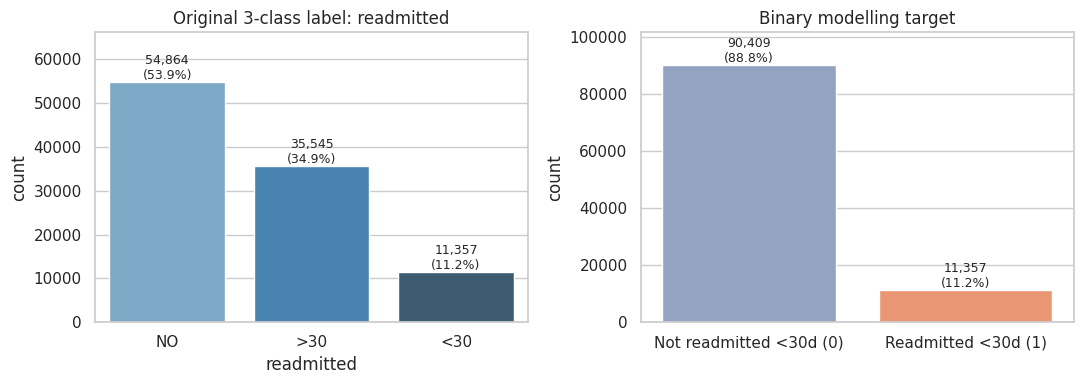

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order3 = ["NO", ">30", "<30"]
sns.countplot(data=df, x=target_col, order=order3, palette="Blues_d", ax=axes[0])
axes[0].set_title("Original 3-class label: readmitted")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():,.0f}\n({p.get_height()/len(df):.1%})",
                     (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, len(df) * 0.65)

sns.countplot(data=df, x="target", palette=["#8da0cb", "#fc8d62"], ax=axes[1])
axes[1].set_xticklabels(["Not readmitted <30d (0)", "Readmitted <30d (1)"])
axes[1].set_title("Binary modelling target")
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():,.0f}\n({p.get_height()/len(df):.1%})",
                     (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(0, len(df) * 1.0)
plt.tight_layout(); plt.show()

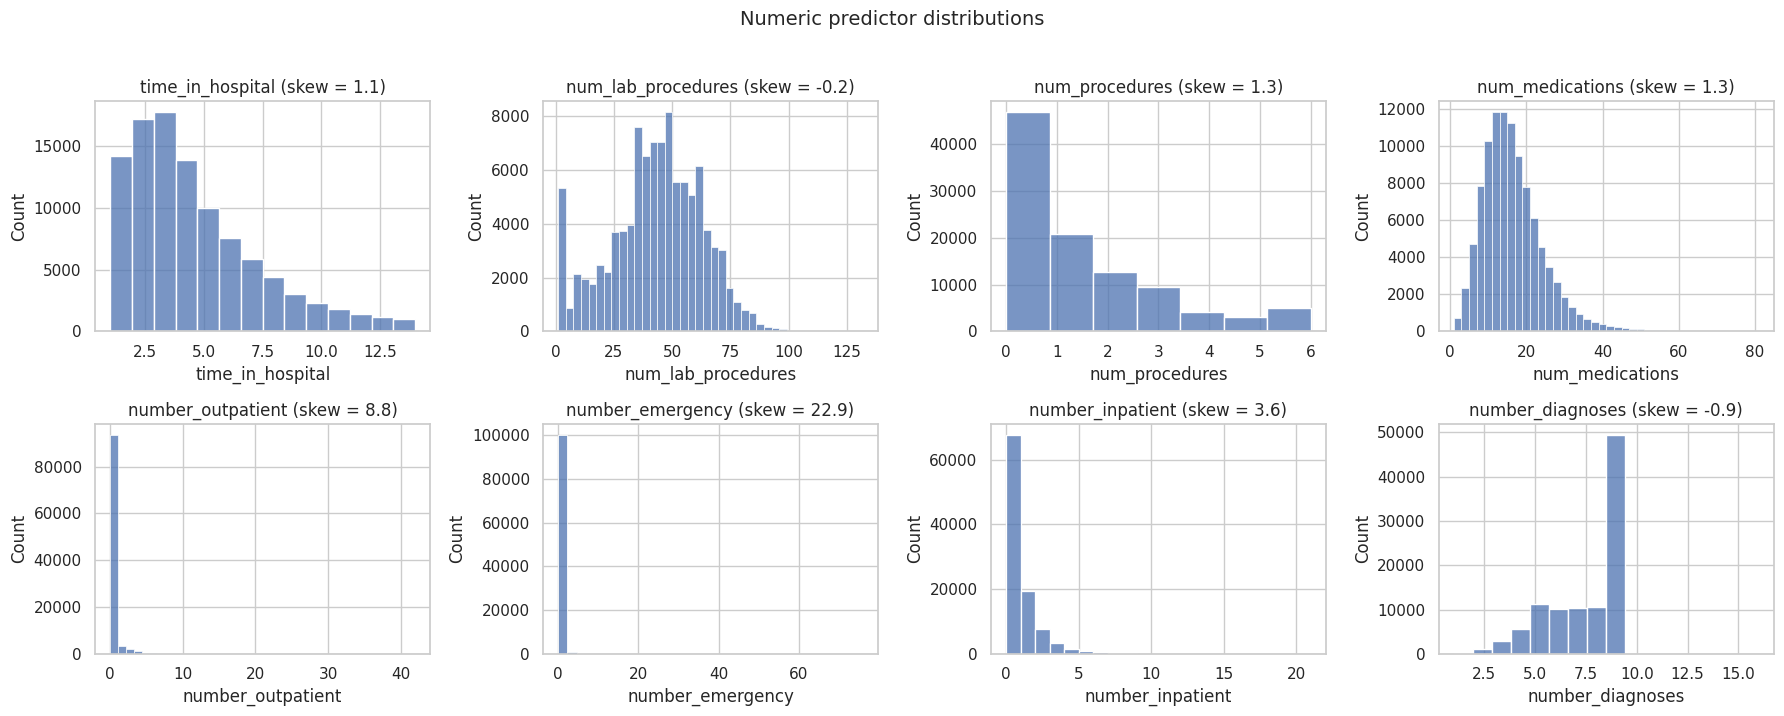

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c], bins=min(40, int(df[c].nunique())), ax=ax, color="#4c72b0")
    ax.set_title(f"{c} (skew = {df[c].skew():.1f})")
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.suptitle("Numeric predictor distributions", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

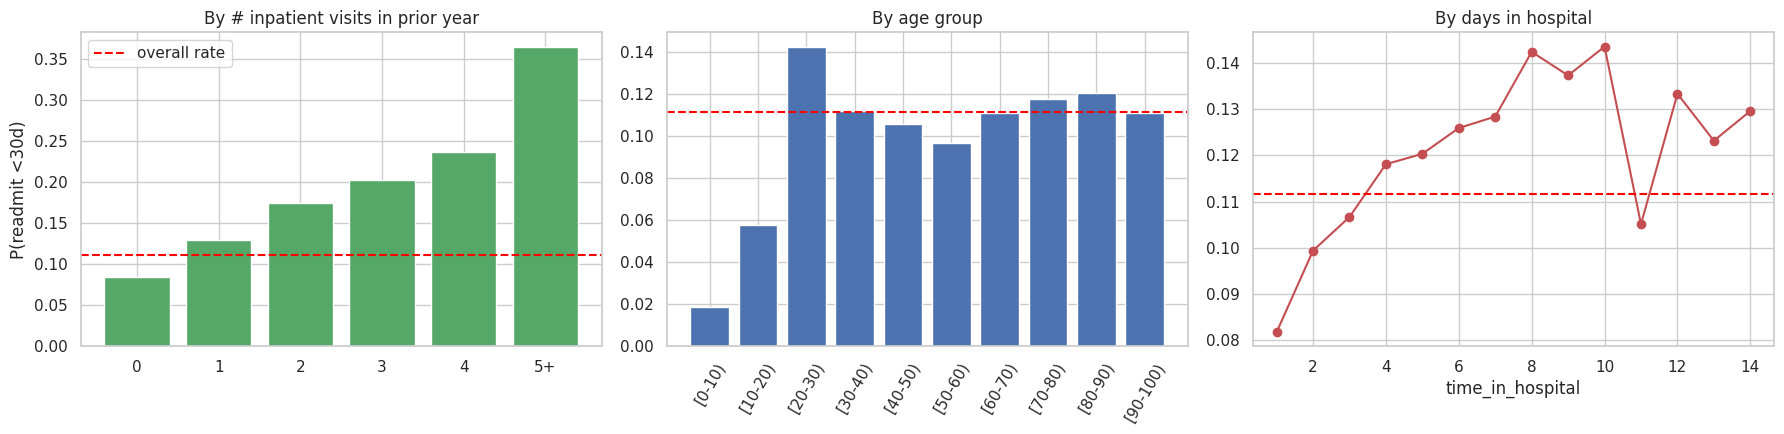

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

tmp = df.assign(prior_inpatient=df["number_inpatient"].clip(upper=5))
r = tmp.groupby("prior_inpatient")["target"].agg(["mean", "count"])
axes[0].bar(r.index.astype(str).str.replace("5", "5+"), r["mean"], color="#55a868")
axes[0].axhline(df["target"].mean(), color="red", ls="--", label="overall rate")
axes[0].set_title("By # inpatient visits in prior year"); axes[0].set_ylabel("P(readmit <30d)"); axes[0].legend()

r = df.groupby("age")["target"].mean()
axes[1].bar(r.index.astype(str), r.values, color="#4c72b0")
axes[1].axhline(df["target"].mean(), color="red", ls="--")
axes[1].set_title("By age group"); axes[1].tick_params(axis="x", rotation=60)

r = df.groupby("time_in_hospital")["target"].mean()
axes[2].plot(r.index, r.values, marker="o", color="#c44e52")
axes[2].axhline(df["target"].mean(), color="red", ls="--")
axes[2].set_title("By days in hospital"); axes[2].set_xlabel("time_in_hospital")
plt.tight_layout(); plt.show()

Data Quality Assessment

In [25]:
miss = pd.DataFrame({"n_missing": df[feature_cols].isna().sum()})
miss["pct_missing"] = miss["n_missing"] / len(df) * 100
print(miss)

                          n_missing  pct_missing
race                           2273        2.234
gender                            0        0.000
age                               0        0.000
weight                        98569       96.858
admission_type_id                 0        0.000
discharge_disposition_id          0        0.000
admission_source_id               0        0.000
time_in_hospital                  0        0.000
payer_code                    40256       39.557
medical_specialty             49949       49.082
num_lab_procedures                0        0.000
num_procedures                    0        0.000
num_medications                   0        0.000
number_outpatient                 0        0.000
number_emergency                  0        0.000
number_inpatient                  0        0.000
diag_1                           21        0.021
diag_2                          358        0.352
diag_3                         1423        1.398
number_diagnoses    

In [19]:
# Improper codings
print("gender values:\n", df["gender"].value_counts(dropna=False), "\n")

if "discharge_disposition_id" in df.columns:
    # IDs 11 = Expired, 13/14 = Hospice, 19/20/21 = Expired variants (per UCI ID mapping)
    dead_hospice = [11, 13, 14, 19, 20, 21]
    d = pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
    n_dead = d.isin(dead_hospice).sum()
    print(f"Encounters ending in death or hospice (cannot be readmitted): {n_dead:,} ({n_dead/len(df):.2%})")
    print("   readmit-<30 rate among them:", round(df.loc[d.isin(dead_hospice), 'target'].mean(), 4))

print("\nInteger-coded columns that are really categories:")
for c in id_coded:
    print(f"   {c}: {df[c].nunique()} distinct codes")

print("\nAge stored as text bins:", sorted(df["age"].dropna().unique())[:4], "...")
print("diag_1 examples (ICD-9; some start with 'V' or 'E'):", df["diag_1"].dropna().sample(6, random_state=1).tolist())
print("diag_1 distinct codes:", df["diag_1"].nunique(), "| diag_2:", df["diag_2"].nunique(), "| diag_3:", df["diag_3"].nunique())

gender values:
 gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64 

Encounters ending in death or hospice (cannot be readmitted): 2,423 (2.38%)
   readmit-<30 rate among them: 0.0177

Integer-coded columns that are really categories:
   admission_type_id: 8 distinct codes
   discharge_disposition_id: 26 distinct codes
   admission_source_id: 17 distinct codes

Age stored as text bins: ['[0-10)', '[10-20)', '[20-30)', '[30-40)'] ...
diag_1 examples (ICD-9; some start with 'V' or 'E'): ['250.6', '996', '440', '250.41', '486', '578']
diag_1 distinct codes: 716 | diag_2: 748 | diag_3: 789


Data Quality Assessment

Several variables like weight, payer_code, medical_speciality, and race have missing values. Since weight is almost entirely missing, i'll probably drop the weight column. The other ones have a missing shares, but I'll create an Unknown category rather than dropping rows because they aren't as depleted.

Patients who passed away or went to hopsice will also be excluded because they can't be readmitted.

Several patients are repeated, so I'll keep one encounter per patient_nbr.


For integer-coded categories (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`), I plan to convert them to categorical, and merge rare codes and codes that mean the same thing. I am also planning on mapping high-cardinality ICD-9 codes to broad diagnostic groups (circulatory, respiratory, diabetes, digestive, injury, musculoskeletal, genitourinary, neoplasms, other).

To handle the class imbalance, I will use class weights and stratified splits when selecting parts of the data for training and validation.

Some challenges with this dataset include the class imbalance, which reduces the meaning of a simple accuracy value since you would score about 89% by predicting not radmitted for everyone, and the large number of missing values that may be informative based on the feature. Also, only readmission to the same system within 30 days is observed, so readmissions elsewhere are not available.

Project Planning

My proposed project problem is, at the time of discharge, predict whether a hospitalized diabetic patient will be readmitted to the hospital within 30 days, using demographics, admission and discharge information, prior-year utilization, laboratory indicators, diagnoses, and medication management.

The target variable is readmitted, suitable for binary in that if readmitted is < 30 then the value is 1, otherwise it is 0.

I am planning to use PR-AUC (Average Precision) as my evaluation metrics, because it is threshold-free and focused on the rare positive class, so it is more informative than ROC-AUC under imbalance (since the positive class is only about 11% of encounters).

UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008